# 02 · Etiketleri görselleştirme
Aşama 3: Gerçek İHA fotoğraflarının etiketlerini kutu ve sınıf adıyla çizmek.

**Kullanım:** Önce **Run All**. Sonra en alttaki hücrede fotoğraf adını değiştirerek başka fotoğraflara bak.

## 1. Hazırlık
Kütüphaneler ve bütün hücrelerde kullanılacak araçlar. Bu bölüm bir kez çalıştırılır.

In [1]:
import numpy as np                 # sayı tabloları
import matplotlib.pyplot as plt    # resim göstermek için
import cv2                         # OpenCV: resim okuma ve çizim

### `yolo_kutu`: etiket satırı → kutu köşeleri
YOLO etiketi oranlarla yazılır (`sınıf merkez_x merkez_y genişlik yükseklik`, hepsi 0–1 arası).
`cv2.rectangle` ise piksel cinsinden **köşe** ister. Bu fonksiyon dönüşümü yapar:
1. oran × fotoğrafın boyutu → piksel
2. merkez ∓ yarım boyut → sol üst ve sağ alt köşe

In [2]:
def yolo_kutu(satir, genislik, yukseklik):        # etiket satırı → kutu köşeleri
    parcalar = satir.split()                      # satırı boşluklardan böl → 5 parçalı liste

    mx = float(parcalar[1]) * genislik            # merkez x  (oran × genişlik)
    my = float(parcalar[2]) * yukseklik           # merkez y  (oran × yükseklik)
    g  = float(parcalar[3]) * genislik            # kutunun genişliği (piksel)
    y  = float(parcalar[4]) * yukseklik           # kutunun yüksekliği (piksel)

    x1 = round(mx - g / 2)                        # sol kenar
    y1 = round(my - y / 2)                        # üst kenar
    x2 = round(mx + g / 2)                        # sağ kenar
    y2 = round(my + y / 2)                        # alt kenar

    return x1, y1, x2, y2                         # sol üst ve sağ alt köşe

### Sözlükler: numaradan isme ve renge
Etikette sınıf bir **numara** olarak yazılı (`1`). İnsan okuyabilsin diye numaradan isme (`car`) ve renge çeviren iki sözlük tutuyoruz. Sınıf isimleri veri setinin `data.yaml` dosyasından geliyor.

In [3]:
siniflar = {                  # sınıf numarası → isim (data.yaml'dan)
    0: "person",
    1: "car",
    2: "bicycle",
    3: "other_vehicle",
    4: "drone",
    5: "mine",
    6: "gun",
}

renkler = {                   # sınıf numarası → renk (BGR sırası!)
    0: (255, 0, 0),           # person        → mavi
    1: (0, 0, 255),           # car           → kırmızı
    2: (0, 255, 0),           # bicycle       → yeşil
    3: (0, 255, 255),         # other_vehicle → sarı
    4: (255, 0, 255),         # drone         → mor
    5: (0, 165, 255),         # mine          → turuncu
    6: (255, 255, 0),         # gun           → açık mavi
}

## 2. Etiketleri çizen fonksiyon
Bir fotoğrafın adını ve bölümünü (`train` / `val` / `test`) alır. Fotoğrafı ve etiketini okur, kutuları ve sınıf adlarını çizip gösterir.

Bu hücreyi çalıştırınca **hiçbir şey görünmez**, sadece tarif tanımlanır.

In [4]:
def etiketleri_ciz(ad, bolum):
    # fotoğrafı oku
    foto = cv2.imread("../data/kucuk_paket/images/" + bolum + "/" + ad + ".png")

    # boyutu al: shape = (yükseklik, genişlik, kanal)
    yukseklik = foto.shape[0]
    genislik  = foto.shape[1]

    # etiket dosyasını oku: aynı ad, labels klasörü, .txt
    with open("../data/kucuk_paket/labels/" + bolum + "/" + ad + ".txt") as dosya:
        etiketler = dosya.read().splitlines()

    # kopya üstüne kutuları ve sınıf adlarını çiz
    cizim = foto.copy()
    for satir in etiketler:
        numara = int(satir.split()[0])                              # sınıf numarası
        x1, y1, x2, y2 = yolo_kutu(satir, genislik, yukseklik)      # köşeler
        cv2.rectangle(cizim, (x1, y1), (x2, y2), renkler[numara], 2)
        cv2.putText(cizim, siniflar[numara], (x1, y1 - 3), cv2.FONT_HERSHEY_SIMPLEX, 0.4, renkler[numara], 1)

    # göster (döngünün DIŞINDA → bir kez)
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(cizim, cv2.COLOR_BGR2RGB))
    plt.title(ad + "   (" + str(len(etiketler)) + " nesne)")
    plt.show()

## 3. Kullanım
Fonksiyonu çağırınca resim çıkar. Başka bir fotoğrafa bakmak için sadece adı ve bölümü değiştir.

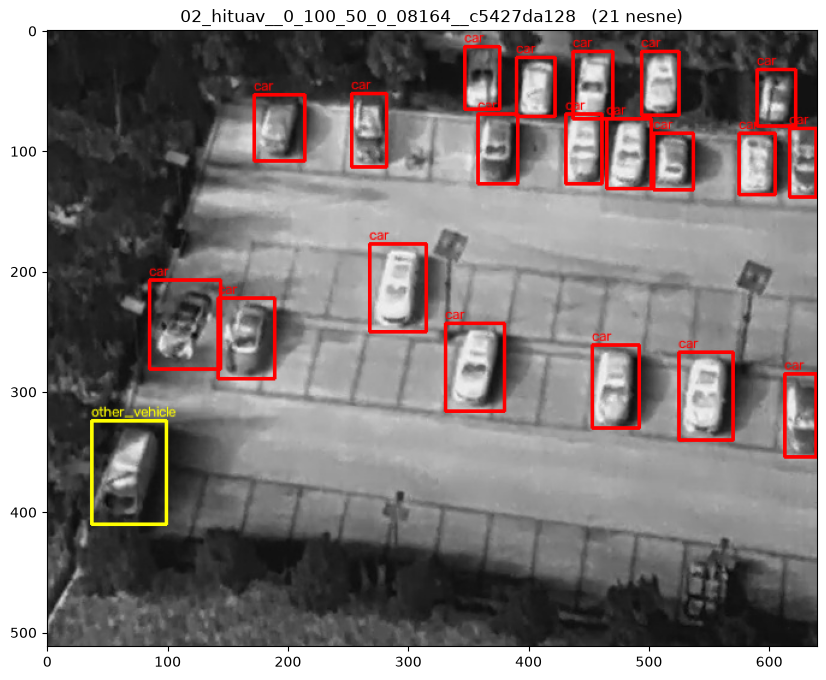

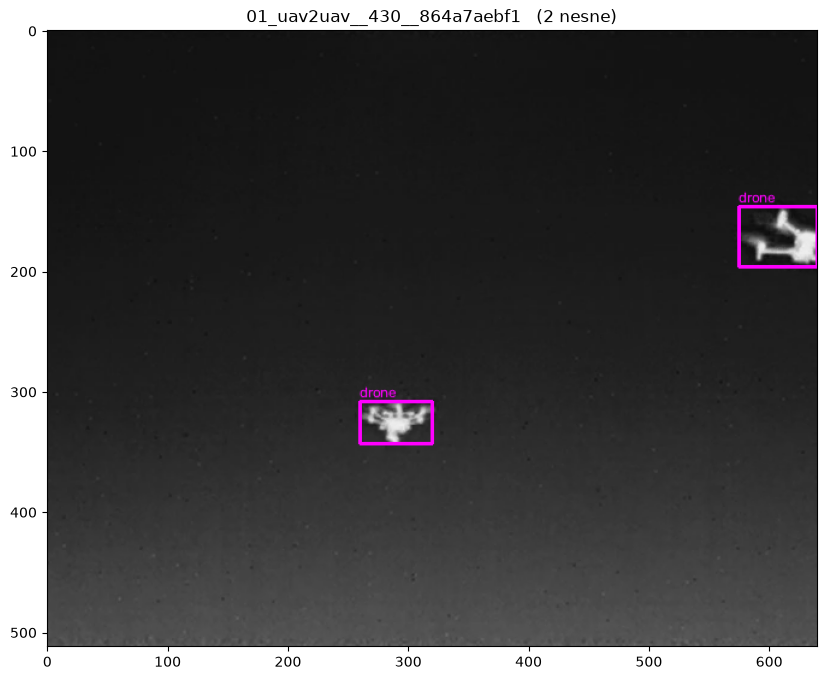

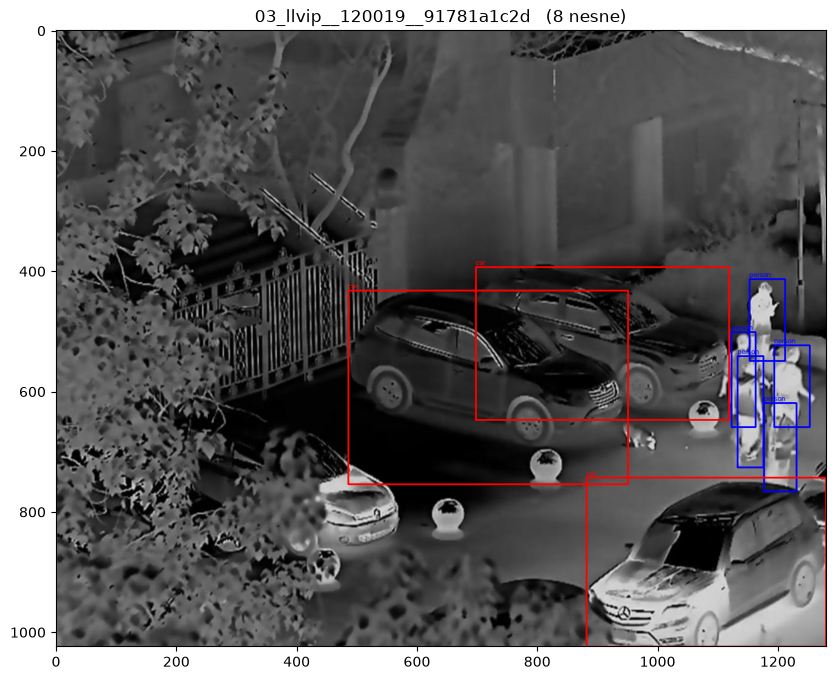

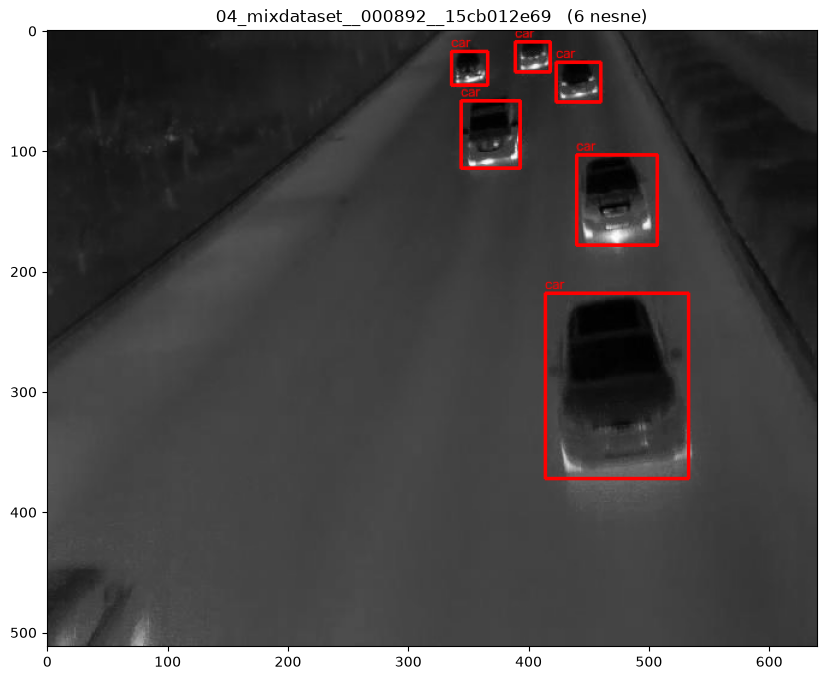

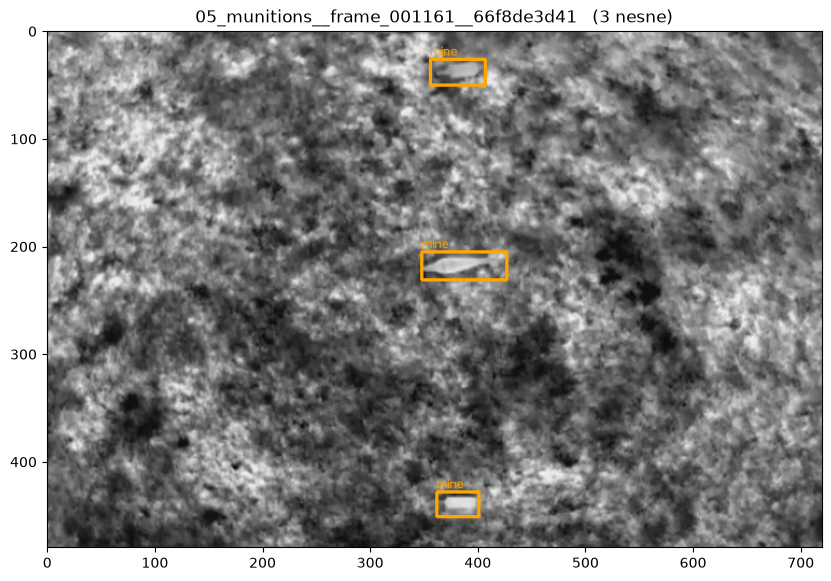

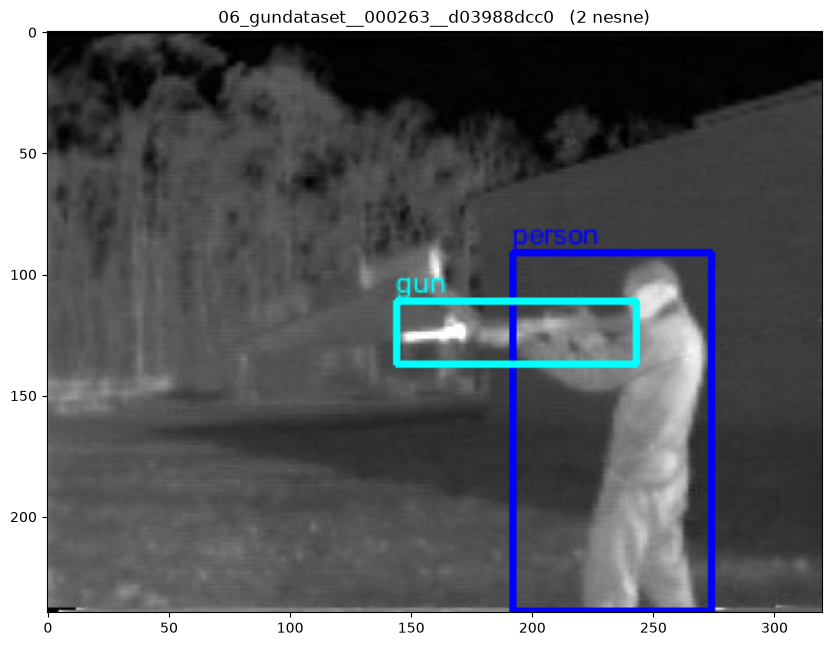

In [5]:
etiketleri_ciz("02_hituav__0_100_50_0_08164__c5427da128", "train")
etiketleri_ciz("01_uav2uav__430__864a7aebf1", "train")
etiketleri_ciz("03_llvip__120019__91781a1c2d", "train")
etiketleri_ciz("04_mixdataset__000892__15cb012e69", "train")
etiketleri_ciz("05_munitions__frame_001161__66f8de3d41", "train")
etiketleri_ciz("06_gundataset__000263__d03988dcc0", "train")


## 4. Klasördeki dosyaları listelemek
Tek tek dosya adı yazmak yerine `os.listdir` ile klasördeki bütün etiket dosyalarını listeliyoruz. Bu sayede 260 fotoğrafı birden inceleyebileceğiz.

In [6]:
import os                                              # dosya ve klasör işlemleri için

dosyalar = os.listdir("../data/kucuk_paket/labels/train")   # klasördeki dosya adları → liste

print(len(dosyalar))        # kaç dosya var
print(dosyalar[0])          # ilk dosyanın adı

260
03_llvip__081054__e584f91eb1.txt


## 5. Toplam nesne sayısı — *biriktirme* kalıbı
`toplam = toplam + ...` kalıbıyla her dosyanın satır sayısını tek bir sayaçta biriktiriyoruz.
Sonuç: 260 dosyada **1.062 nesne**.

In [7]:
toplam = 0                                             # sayaç: sıfırdan başla

for dosya_adi in dosyalar:                             # 260 dosyanın her biri için:
    with open("../data/kucuk_paket/labels/train/" + dosya_adi) as dosya:
        satirlar = dosya.read().splitlines()           #   dosyayı oku, satırlara ayır
    toplam = toplam + len(satirlar)                    #   satır sayısını toplama ekle

print(toplam)

1062


## 6. Tek fotoğraftaki kutuların alanı — `append`
Önce işi küçük tutuyoruz: bir fotoğraftaki her kutunun kapladığı alanı (`genişlik × yükseklik`) hesaplayıp bir listeye ekliyoruz.
Otoparkta bir kutu diğerlerinden belirgin büyük çıkıyor: o, `other_vehicle` (kamyonet).

In [8]:
ad = "02_hituav__0_100_50_0_08164__c5427da128"

foto = cv2.imread("../data/kucuk_paket/images/train/" + ad + ".png")
yukseklik = foto.shape[0]
genislik  = foto.shape[1]

with open("../data/kucuk_paket/labels/train/" + ad + ".txt") as dosya:
    etiketler = dosya.read().splitlines()

alanlar = []                                                  # boş liste

for satir in etiketler:
    x1, y1, x2, y2 = yolo_kutu(satir, genislik, yukseklik)    # köşeler
    alan = (x2 - x1) * (y2 - y1)                              # genişlik × yükseklik
    alanlar.append(alan)                                      # listeye ekle

print(alanlar)

[1508, 1568, 1848, 1643, 1504, 2310, 1769, 1914, 1740, 2146, 1551, 1530, 1254, 3431, 3577, 2691, 3285, 1794, 3149, 4366, 5332]


## 7. Bütün veri: sınıf başına kutu boyutu — *iç içe döngü*
İki kat döngü var:
- **Dış döngü:** klasördeki her dosya (fotoğraf)
- **İç döngü:** o dosyadaki her satır (nesne)

Her nesnenin boyutu `kenarlar[numara]` ile **kendi sınıfının listesine** yazılır. `np.sqrt(alan)` kutuyu kareye çevirip "bir kenarı kaç piksel?" sorusunu cevaplar.

In [9]:
import os

kenarlar = {0: [], 1: [], 2: [], 3: [], 4: [], 5: [], 6: []}    # her sınıf için boş bir defter

for dosya_adi in os.listdir("../data/kucuk_paket/labels/train"):  # DIŞ: her dosyaya (sınıfa) gir
    ad = dosya_adi.replace(".txt", "")
    foto = cv2.imread("../data/kucuk_paket/images/train/" + ad + ".png")
    yukseklik = foto.shape[0]
    genislik  = foto.shape[1]
    with open("../data/kucuk_paket/labels/train/" + dosya_adi) as dosya:
        satirlar = dosya.read().splitlines()

    for satir in satirlar:                                        #   İÇ: o dosyadaki her nesne (öğrenci)
        numara = int(satir.split()[0])                            #     hangi sınıftan
        x1, y1, x2, y2 = yolo_kutu(satir, genislik, yukseklik)    #     kutunun köşeleri
        alan = (x2 - x1) * (y2 - y1)                              #     kaç piksel kaplıyor
        kenarlar[numara].append(np.sqrt(alan))                    #     o sınıfın defterine yaz

for numara in kenarlar:                                           # sonuç: her sınıf için bir satır
    print(f"{siniflar[numara]:15} {len(kenarlar[numara]):4} kutu   tipik kenar: {np.median(kenarlar[numara]):4.0f} piksel")

person           339 kutu   tipik kenar:   92 piksel
car              266 kutu   tipik kenar:   56 piksel
bicycle          259 kutu   tipik kenar:   25 piksel
other_vehicle     21 kutu   tipik kenar:   59 piksel
drone             40 kutu   tipik kenar:   44 piksel
mine              95 kutu   tipik kenar:   35 piksel
gun               42 kutu   tipik kenar:   53 piksel


## 8. Grafik: hangi sınıfın nesneleri ne kadar büyük?
Her sınıfın **ortanca** kutu kenarı. Ortanca, birkaç aşırı büyük kutudan ortalamaya göre daha az etkilenir.

**Bulgu:** En küçük nesneler `bicycle` (25 px) ve `mine` (35 px). Küçük nesneleri tespit etmek zordur: az piksel = az bilgi. Modelin bu sınıflarda zorlanmasını bekliyoruz.

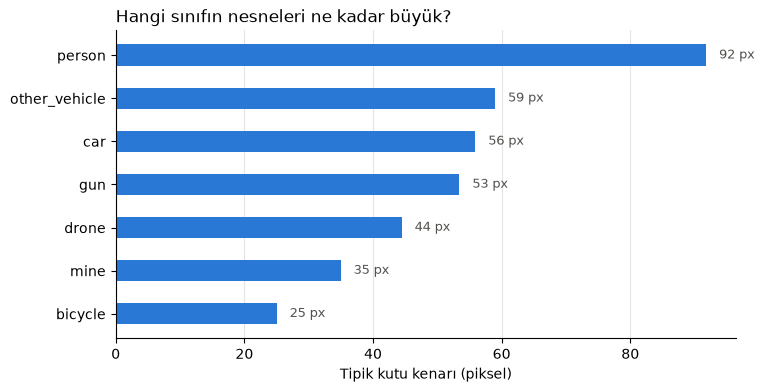

In [10]:
sirali   = sorted(kenarlar, key=lambda n: np.median(kenarlar[n]))   # sınıfları küçükten büyüğe diz
isimler  = [siniflar[n] for n in sirali]
degerler = [np.median(kenarlar[n]) for n in sirali]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(isimler, degerler, height=0.5, color="#2a78d6")            # yatay çubuklar
for i, d in enumerate(degerler):
    ax.text(d + 2, i, f"{d:.0f} px", va="center", color="#52514e", fontsize=9)   # çubuğun ucuna değer
ax.set_xlabel("Tipik kutu kenarı (piksel)")
ax.set_title("Hangi sınıfın nesneleri ne kadar büyük?", loc="left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="#e5e4e0")
ax.set_axisbelow(True)
plt.show()

## Bu sayfanın özeti
- Etiketler kutu + sınıf adı olarak fotoğrafın üstüne çizildi (`etiketleri_ciz`)
- 6 kaynağın hepsine bakıldı: hepsi **termal**, her kaynak belirli sınıflarda uzman
- 260 dosyadaki 1.062 nesne ölçüldü, sınıf başına tipik kutu boyutu çıkarıldı

**Not:** Bu sayfadaki kod nesneleri *bulmuyor*, insanların önceden çizdiği etiketleri *okuyor*. Nesneyi fotoğraftan bulmak YOLO'nun işi.